# **Tipo de problema**
El presente análisis aborda un problema de **clasificación binaria**, donde se busca determinar si un cliente abandonará el servicio (Yes) o permanecerá activo (No), a partir de **variables comerciales, contractuales y de comportamiento.**

# **Objetivo**
El objetivo es identificar los factores clave que influyen en el **abandono de clientes y desarrollar un modelo predictivo** que permita anticipar qué clientes presentan mayor riesgo de churn. Esta información busca apoyar la toma de decisiones de negocio, facilitando el diseño de estrategias de retención, optimización de contratos y mejora de la oferta de servicios, con el fin de reducir la **pérdida de clientes y proteger los ingresos de la empresa.**

In [36]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Graficos
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Modelado
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt





In [37]:
# Cargamos los datos
df = pd.read_csv('/content/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [39]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [40]:
# Cambiamos nombres de columnas
df.columns = ['ID de cliente', 'género', 'Jubilado', 'Socio', 'Dependientes',
'Antigüedad', 'Servicio telefónico', 'Líneas múltiples', 'Servicio de internet',
'Seguridad en línea', 'Copia de seguridad en línea', 'Protección del dispositivo', 'Soporte técnico',
'Transmisión de TV', 'Transmisión de películas', 'Contrato', 'Facturación electrónica',
'Método de pago', 'Cargos mensuales', 'Cargos totales', 'Abandono de clientes']


In [41]:
# Número de datos faltantes por variable
df.isna().sum().sort_values()

,0
ID de cliente,0
género,0
Jubilado,0
Socio,0
Dependientes,0
Antigüedad,0
Servicio telefónico,0
Líneas múltiples,0
Servicio de internet,0
Seguridad en línea,0


In [42]:
df = df.drop(columns=['ID de cliente'])

In [43]:
# Reemplazar espacios vacíos en 'Cargos totales' por NaN
df['Cargos totales'] = df['Cargos totales'].replace(" ", np.nan)

# Convertir Cargos totales a numérico
df['Cargos totales'] = pd.to_numeric(df['Cargos totales'])

# Ver cuántos NaN quedaron
df['Cargos totales'].isna().sum()

np.int64(11)

In [44]:
# Eliminamos los NaN y verificamos la cantidad de filas
df = df.dropna(subset=['Cargos totales'])
df.shape

(7032, 20)

In [45]:
# Resumen estadístico, verificamos variables numéricas
df.describe()

,Jubilado,Antigüedad,Cargos mensuales,Cargos totales
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [46]:
# Valores únicos tiene cada columna
df.nunique()

,0
género,2
Jubilado,2
Socio,2
Dependientes,2
Antigüedad,72
Servicio telefónico,2
Líneas múltiples,3
Servicio de internet,3
Seguridad en línea,3
Copia de seguridad en línea,3


In [47]:
# Identificar columnas numéricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns
numericas



Index(['Jubilado', 'Antigüedad', 'Cargos mensuales', 'Cargos totales'], dtype='object')

In [48]:
# Identificar columnas categóricas
categoricas = df.select_dtypes(include=['object']).columns
categoricas

Index(['género', 'Socio', 'Dependientes', 'Servicio telefónico',
       'Líneas múltiples', 'Servicio de internet', 'Seguridad en línea',
       'Copia de seguridad en línea', 'Protección del dispositivo',
       'Soporte técnico', 'Transmisión de TV', 'Transmisión de películas',
       'Contrato', 'Facturación electrónica', 'Método de pago',
       'Abandono de clientes'],
      dtype='object')

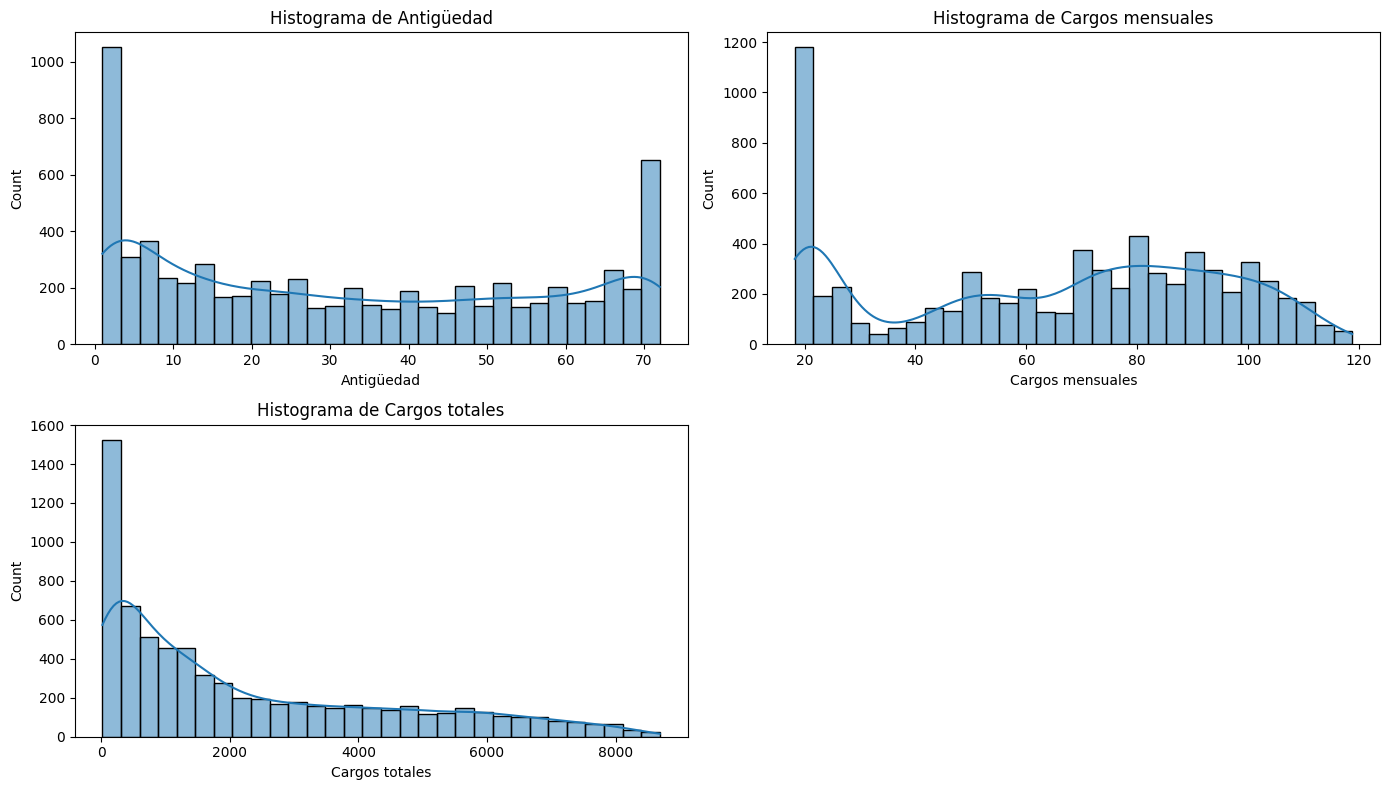

In [49]:
# HISTOGRAMAS variables numericas

numericas = ['Antigüedad', 'Cargos mensuales', 'Cargos totales']

plt.figure(figsize=(14,8))

for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histograma de {col}')

plt.tight_layout()
plt.show()

#Antiguedad:
La empresa tiene una gran cantidad de clientes nuevos y pocos clientes con mucha permanencia.
Esto sugiere un servicio con alta rotación natural o dificultades de retención temprana.
#Cargos mensuales:
Los clientes se agrupan por tipo de paquete (DSL, fibra óptica, servicios extra).
La heterogeneidad de precios sugiere que hay múltiples configuraciones de servicios, importante a la hora de estudiar churn.
#Cargos totales:
La empresa tiene muchos clientes nuevos con poca facturación acumulada.
Los clientes más antiguos representan un grupo reducido pero valioso

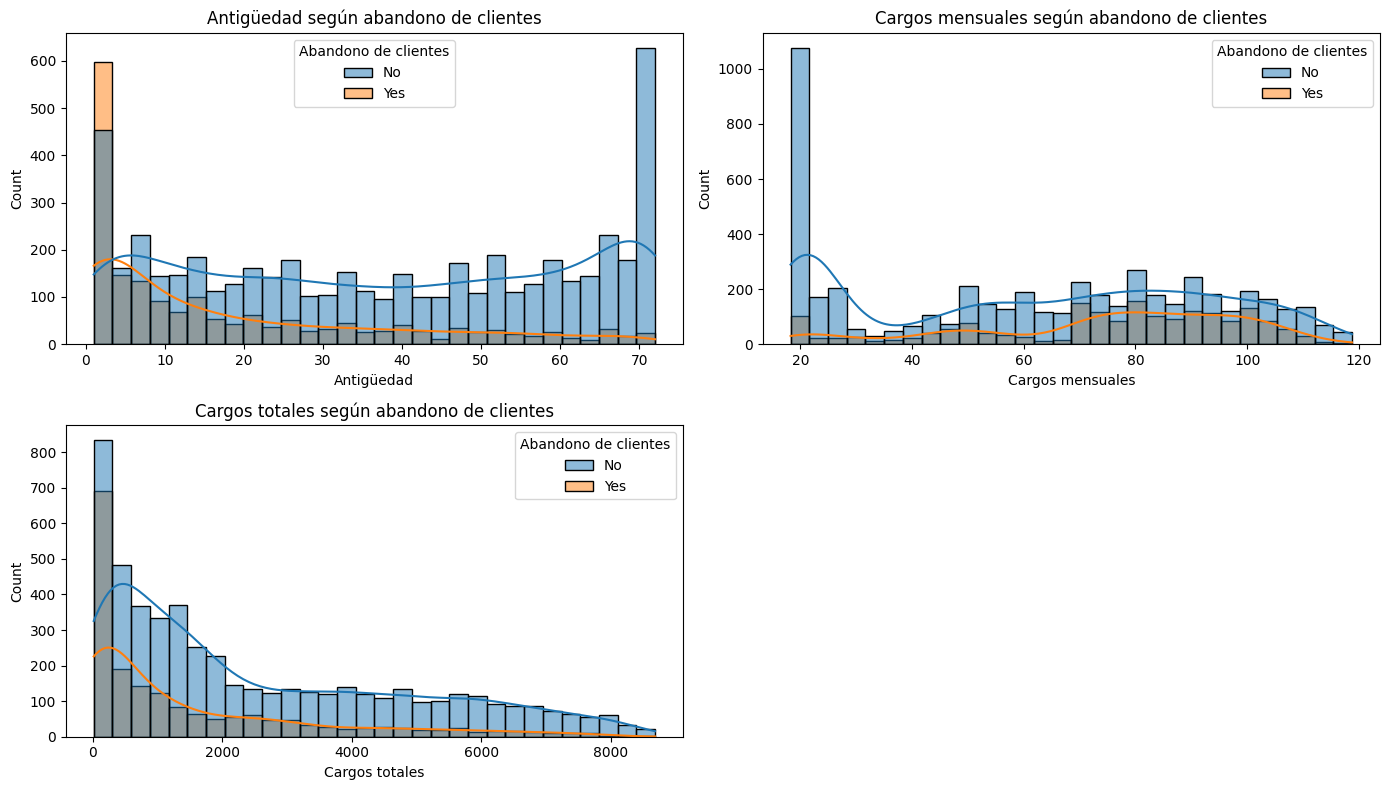

In [50]:
# HISTOGRMAS comparamos Clientes que "abandonan vs No abandonan"

plt.figure(figsize=(14,8))

for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, hue='Abandono de clientes', bins=30, kde=True)
    plt.title(f'{col} según abandono de clientes')

plt.tight_layout()
plt.show()


#Antiguedad vs Abandono:

La antigüedad es uno de los principales predictores de churn.
Los clientes nuevos son extremadamente vulnerables a abandonar el servicio.

#Cargos mensuales vs Abandono:
El costo del servicio es un factor de riesgo crítico.
Planes más caros → mayor tendencia a rescindir el contrato.
Esto se relaciona con servicios premium como fibra óptica.

# Cargos totales vs Abandono:
Esto confirma lo que vimos en antigüedad:
clientes nuevos + poca facturación = riesgo altísimo.


#*CONCLUSION:
En conjunto, estos hallazgos indican que los esfuerzos de retención deberían centrarse en:
(1) nuevos clientes durante los primeros meses,
(2) clientes con cargos mensuales altos,
(3) ofrecer incentivos o revisiones de planes a usuarios premium para reducir el riesgo de abandono.



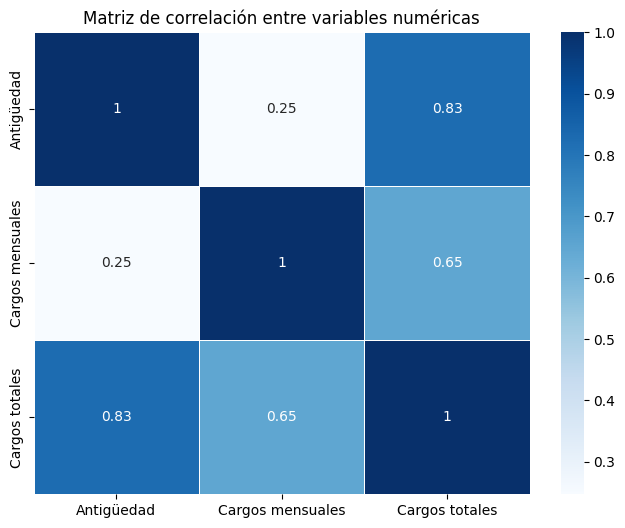

In [51]:
#MATRIZ de CORRELACION

# Seleccionamos solo las variables numéricas
numericas = ['Antigüedad', 'Cargos mensuales', 'Cargos totales']

# Matriz de correlación
corr = df[numericas].corr()

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues', linewidths=.5)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

#Conclusion:
La correlación confirma que la antigüedad es una variable fundamental en el comportamiento del cliente. También valida que los cargos totales son, en esencia, una consecuencia directa del tiempo que el cliente lleva con la empresa y no tanto del monto mensual que paga.
Estos hallazgos refuerzan la idea de que la retención debe concentrarse en clientes nuevos y en aquellos con baja facturación acumulada, ya que estos representan el mayor riesgo de abandono.

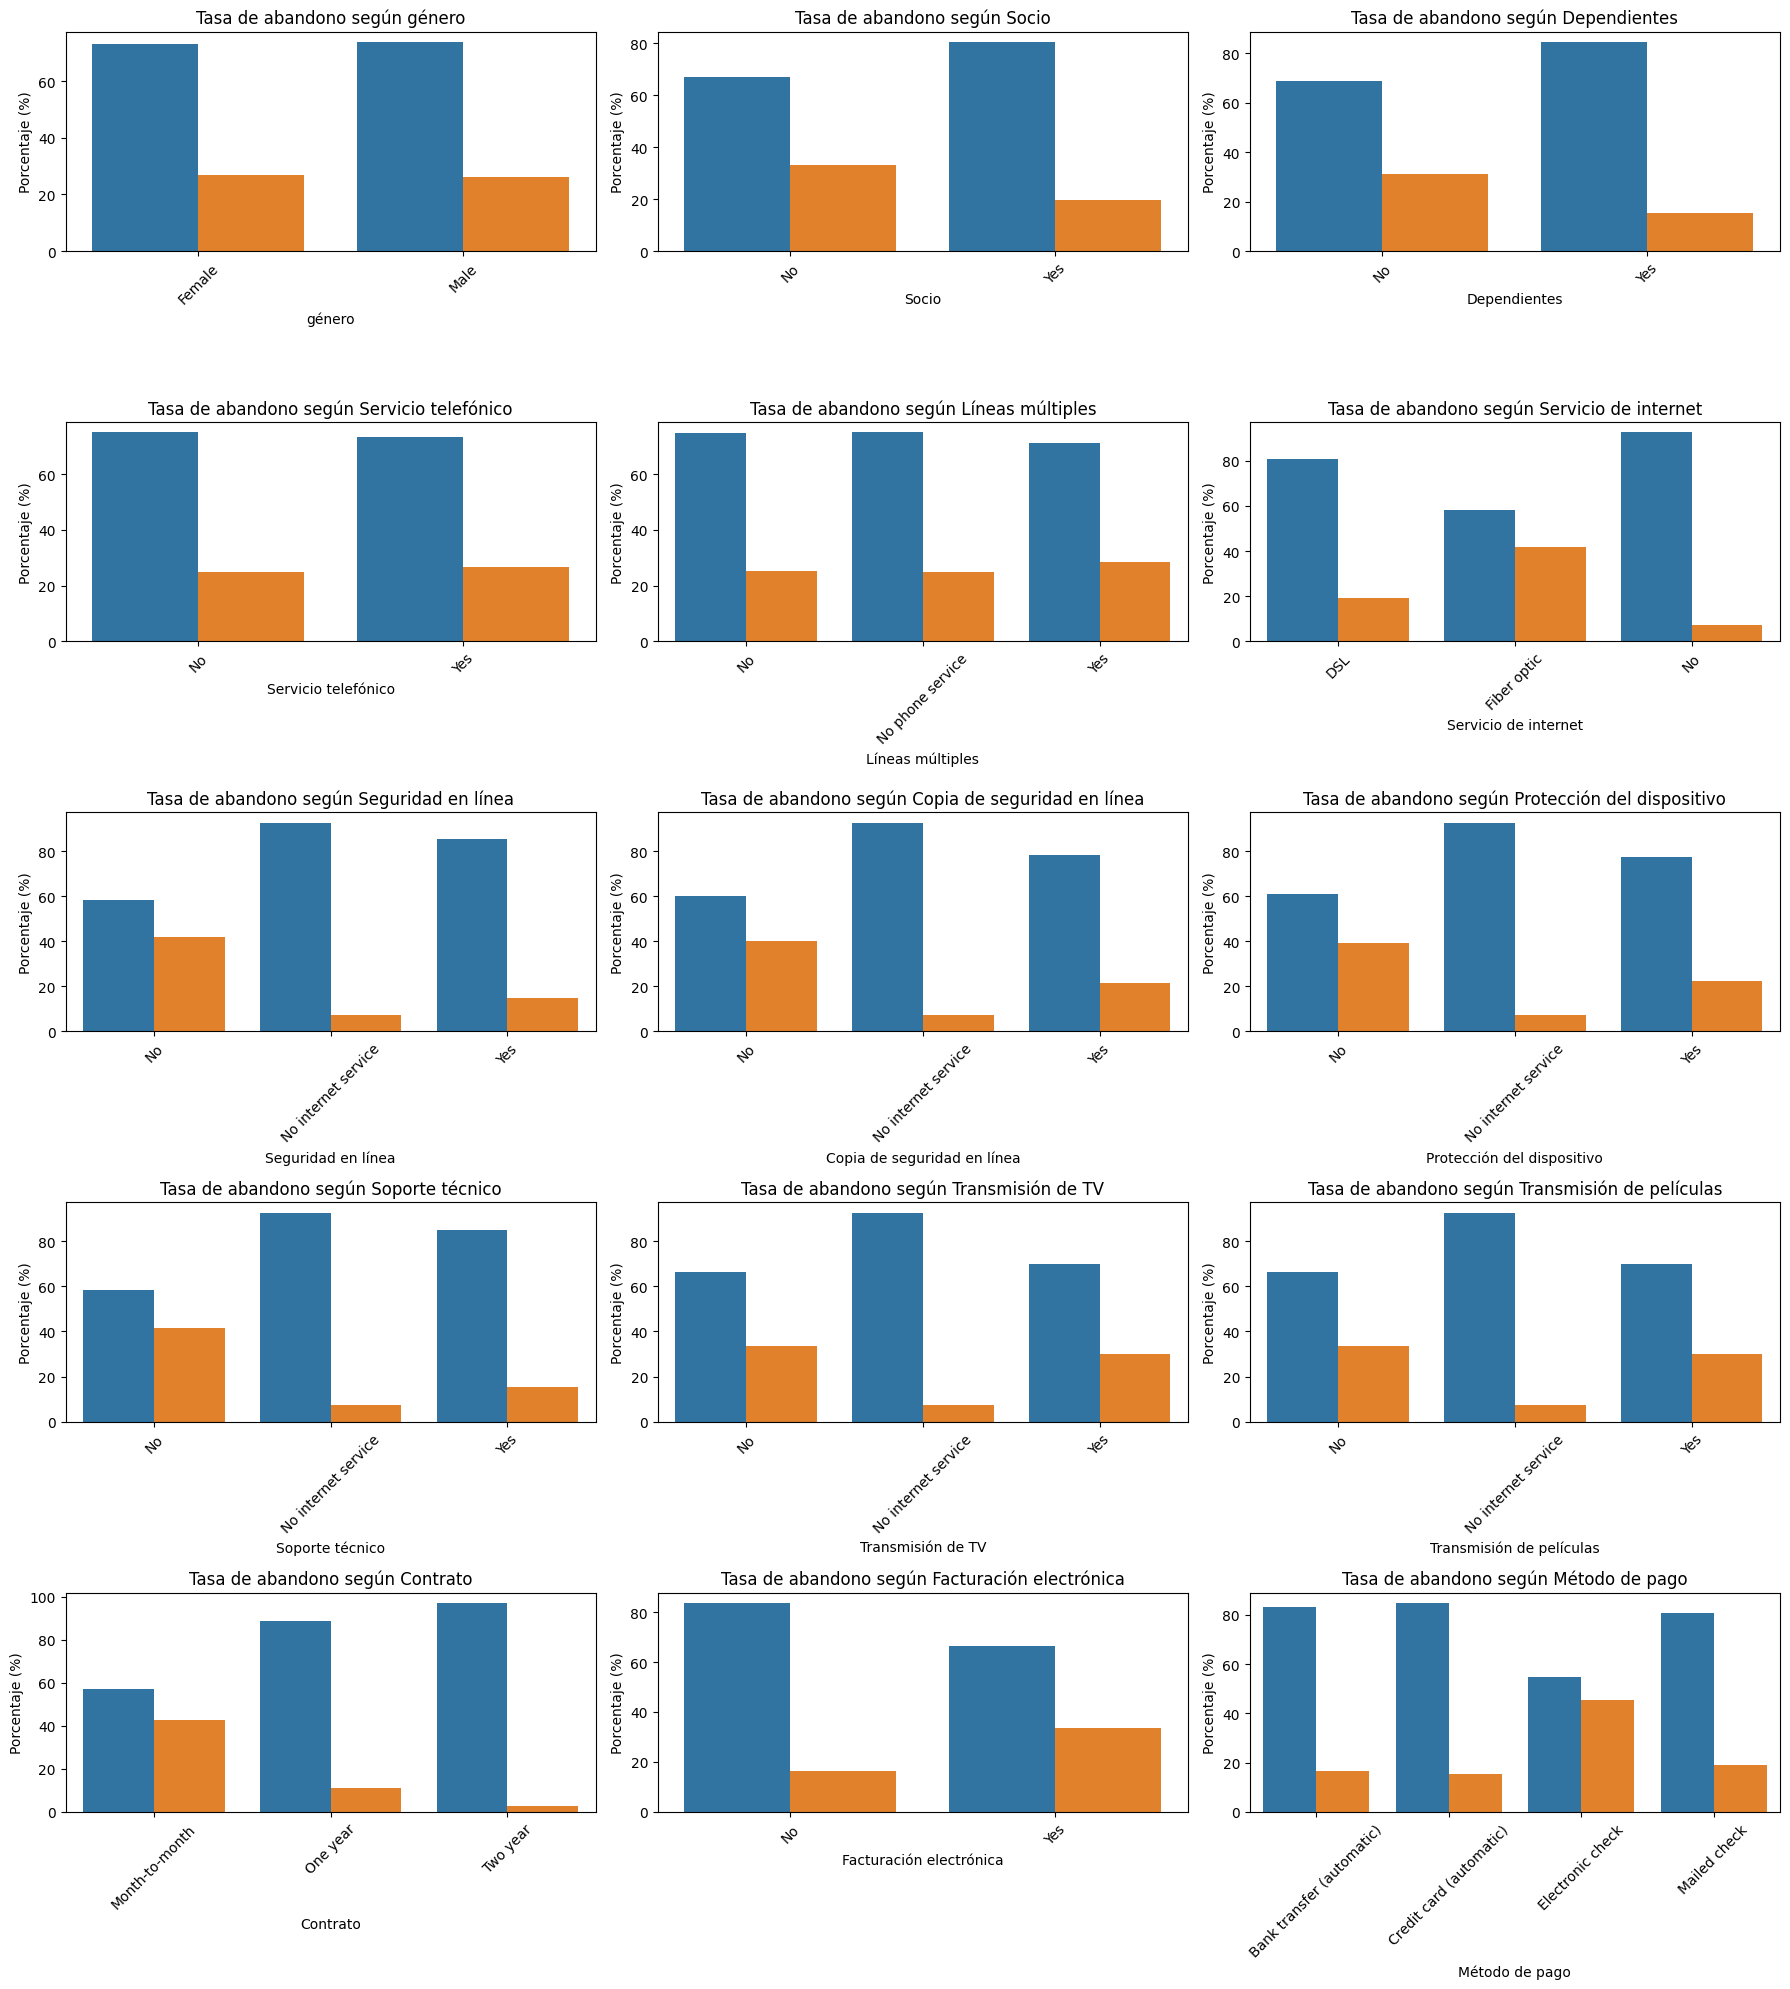

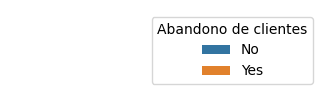

In [52]:
# VARIABLES CATEGÓRICAS
# Análisis de variables categóricas, para entender qué factores NO numéricos explican el abandono.

# Seleccionar solo variables categóricas
categoricas = df.select_dtypes(include=['object']).columns.tolist()

# Asegurar que la variable objetivo NO esté en la lista
if 'Abandono de clientes' in categoricas:
    categoricas.remove('Abandono de clientes')

graficos_por_fila = 3
filas = math.ceil(len(categoricas) / graficos_por_fila)

plt.figure(figsize=(18, filas * 4))

for i, col in enumerate(categoricas, 1):

    plt.subplot(filas, graficos_por_fila, i)

    prop = (
        df.groupby(col)['Abandono de clientes']
        .value_counts(normalize=True)
        .rename('proportion')
        .mul(100)
        .reset_index()
    )

    sns.barplot(
        data=prop,
        x=col,
        y='proportion',
        hue='Abandono de clientes',
        palette=['#1f77b4', '#ff7f0e']
    )

    plt.title(f"Tasa de abandono según {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Porcentaje (%)")

    # Quitamos leyenda individual
    plt.legend([], [], frameon=False)

plt.tight_layout()
plt.show()

# ---- LEYENDA GENERAL ----
# Usamos un DataFrame con dos filas creadas a mano para no depender del último loop.
legend_df = pd.DataFrame({
    'Abandono de clientes': ['No', 'Yes'],
    'proportion': [0, 0],              # valores ficticios
    'dummy': ['A', 'A']                # columna dummy obligatoria para X
})

plt.figure(figsize=(4, 1))
sns.barplot(
    data=legend_df,
    x='dummy',
    y='proportion',
    hue='Abandono de clientes',
    palette=['#1f77b4', '#ff7f0e']
)
plt.legend(title="Abandono de clientes")
plt.axis('off')
plt.show()


# Analisis general:
El análisis categórico muestra que el abandono de clientes no es aleatorio, sino que responde a características muy claras del servicio y del tipo de cliente. Las variables con mayor impacto negativo en la retención son los contratos mes a mes, el uso de fibra óptica, la ausencia de servicios de seguridad o soporte técnico, y los métodos de pago menos automatizados, como el “electronic check”.
Por el contrario, los clientes con contratos anuales o bianuales, servicios adicionales activos, y métodos de pago automáticos muestran tasas de abandono significativamente menores.
Estos resultados indican que la empresa tiene oportunidades concretas de retención: incentivar la migración hacia contratos más largos, ofrecer paquetes de valor agregado, y promover métodos de pago automáticos para reducir la probabilidad de abandono.

In [53]:
#Eliminamos columnas irrelevantes para el analisis, debido a su poca influencia sobre la variable a predecir
columnas_eliminar = [
    'género',
    'Servicio telefónico',
    'Líneas múltiples',
    'Transmisión de TV',
    'Transmisión de películas'
]

df = df.drop(columns=columnas_eliminar)

df.head()

,Jubilado,Socio,Dependientes,Antigüedad,Servicio de internet,Seguridad en línea,Copia de seguridad en línea,Protección del dispositivo,Soporte técnico,Contrato,Facturación electrónica,Método de pago,Cargos mensuales,Cargos totales,Abandono de clientes
0,0,Yes,No,1,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.50,No
2,0,No,No,2,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
df.shape

(7032, 15)

,proportion
Abandono de clientes,
No,0.734215
Yes,0.265785


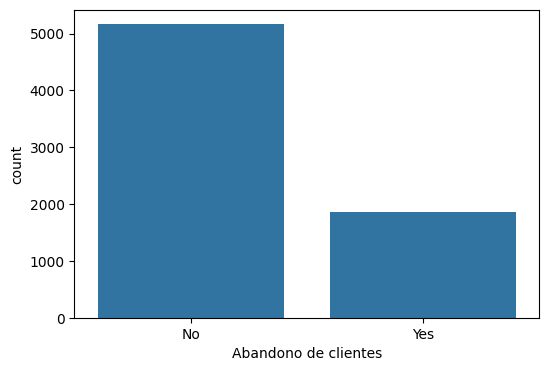

In [55]:
# Distribucion de la variable target ('Abandono de clientes')

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Abandono de clientes')
df['Abandono de clientes'].value_counts(normalize=True)

In [56]:
# Identificar columnas numéricas y categóricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

# Eliminamos la variable objetivo de las categóricas
categoricas.remove('Abandono de clientes')

numericas, categoricas

(['Jubilado', 'Antigüedad', 'Cargos mensuales', 'Cargos totales'],
 ['Socio',
  'Dependientes',
  'Servicio de internet',
  'Seguridad en línea',
  'Copia de seguridad en línea',
  'Protección del dispositivo',
  'Soporte técnico',
  'Contrato',
  'Facturación electrónica',
  'Método de pago'])

#Preparacion DATASET


In [57]:
# ====== SEPARAR X e y ======
X = df.drop(columns=['Abandono de clientes'])
y = df['Abandono de clientes']

# ====== TRAIN / TEST SPLIT ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ====== IDENTIFICAR COLUMNAS ======
numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = X.select_dtypes(include=['object']).columns.tolist()

numericas, categoricas

(['Jubilado', 'Antigüedad', 'Cargos mensuales', 'Cargos totales'],
 ['Socio',
  'Dependientes',
  'Servicio de internet',
  'Seguridad en línea',
  'Copia de seguridad en línea',
  'Protección del dispositivo',
  'Soporte técnico',
  'Contrato',
  'Facturación electrónica',
  'Método de pago'])

# Pipelines:

In [58]:
# Creamos el procesador (Column Transformer)
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
        ('num', StandardScaler(), numericas)
    ]
)
# PIPELINE 1 (Regresion Logistica - Balance Automatico)

pipeline_log = ImbPipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('smote', SMOTE(random_state=42)),
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Creamos el procesador (Random Forest - sin escalar)

preprocesador_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
        ('num', 'passthrough', numericas)  # no escalamos
    ]
)
# PIPELINE 2 (Random Forest)
pipeline_rf = ImbPipeline(steps=[
    ('preprocesamiento', preprocesador_rf),
    ('smote', SMOTE(random_state=42)),
    ('modelo', RandomForestClassifier(n_estimators=300, random_state=42))
])

#Entrenamiento y Prediccion:

In [59]:
# ====== ENTRENAR MODELOS ======
pipeline_log.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

# ====== PREDICCIONES ======
y_pred_log = pipeline_log.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

# ====== FUNCIÓN DE EVALUACIÓN ======
def evaluar(y_test, y_pred, nombre):
    print(f"\n🔵 RESULTADOS DEL MODELO: {nombre}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, pos_label='Yes'))
    print("Recall:", recall_score(y_test, y_pred, pos_label='Yes'))
    print("F1 Score:", f1_score(y_test, y_pred, pos_label='Yes'))
    print("\nReporte completo:\n", classification_report(y_test, y_pred))

# ====== EVALUACIÓN ======
evaluar(y_test, y_pred_log, "Regresión Logística")
evaluar(y_test, y_pred_rf, "Random Forest")


🔵 RESULTADOS DEL MODELO: Regresión Logística
Accuracy: 0.7369668246445498
Precision: 0.5033632286995515
Recall: 0.8003565062388592
F1 Score: 0.6180316586373021

Reporte completo:
               precision    recall  f1-score   support

          No       0.91      0.71      0.80      1549
         Yes       0.50      0.80      0.62       561

    accuracy                           0.74      2110
   macro avg       0.71      0.76      0.71      2110
weighted avg       0.80      0.74      0.75      2110


🔵 RESULTADOS DEL MODELO: Random Forest
Accuracy: 0.7729857819905214
Precision: 0.586864406779661
Recall: 0.49376114081996436
F1 Score: 0.5363020329138432

Reporte completo:
               precision    recall  f1-score   support

          No       0.83      0.87      0.85      1549
         Yes       0.59      0.49      0.54       561

    accuracy                           0.77      2110
   macro avg       0.71      0.68      0.69      2110
weighted avg       0.76      0.77      0.77  

In [60]:
import pandas as pd

# Copia del dataset usado para predicción
df_final = X_test.copy()

# Abandono real
df_final["Abandono_real"] = y_test.values

# Predicción del modelo (0/1)
df_final["Prediccion_abandono"] = y_pred_log # Usamos la predicción de Regresión Logística

# Probabilidad de abandono (clase positiva)
df_final["Probabilidad_abandono"] = pipeline_log.predict_proba(X_test)[:, 1] # Usamos el pipeline de Regresión Logística

df_final.head()

,Jubilado,Socio,Dependientes,Antigüedad,Servicio de internet,Seguridad en línea,Copia de seguridad en línea,Protección del dispositivo,Soporte técnico,Contrato,Facturación electrónica,Método de pago,Cargos mensuales,Cargos totales,Abandono_real,Prediccion_abandono,Probabilidad_abandono
4221,0,No,No,1,No,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),19.30,19.30,No,No,0.409439
1820,0,Yes,No,6,DSL,No,No,No,No,Month-to-month,No,Mailed check,45.65,323.45,No,Yes,0.645078
2375,1,Yes,No,71,Fiber optic,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),109.70,7904.25,No,No,0.144635
5462,0,Yes,No,64,DSL,No,Yes,No,Yes,One year,Yes,Mailed check,70.15,4480.70,No,No,0.098568
1791,0,Yes,No,44,DSL,Yes,Yes,Yes,No,One year,Yes,Mailed check,61.50,2722.20,No,No,0.127431


In [62]:
# Forzar tipo float (seguridad extra)
df_final["Probabilidad_abandono"] = df_final["Probabilidad_abandono"].astype("float64")

# Exportación compatible con Power BI en español
df_final.to_csv(
    "clientes_churn_predictivo_OK.csv",
    index=False,
    sep=";",        # separador correcto en ES
    decimal=",",    # decimal correcto en ES
    encoding="utf-8"
)



In [63]:
from google.colab import files
files.download("clientes_churn_predictivo_OK.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



*  **Descargamos el nuevo Df** "clientes_churn_predictivo.csv"



#**> Hallazgos claves del analisis y modelo recomendado**
-El análisis integral del dataset confirma que el abandono de clientes responde a patrones estructurales claramente identificables, y no a un comportamiento aleatorio. Variables relacionadas con la modalidad contractual, la ausencia de servicios complementarios y ciertos métodos de pago presentan una incidencia directa en el incremento del riesgo de abandono.

En el proceso de modelado se evaluaron dos enfoques predictivos: Regresión Logística y Random Forest. Si bien el modelo Random Forest alcanzó una mayor exactitud global, la **Regresión Logística demostró una mayor eficacia en la identificación de clientes con riesgo real de abandono, logrando detectar aproximadamente el 80% de los casos positivos.**

Dado que el objetivo principal del negocio es anticipar la pérdida de clientes, el modelo de Regresión Logística se considera el más adecuado, ya que prioriza la detección temprana del riesgo por sobre la precisión general, alineándose de forma más efectiva con las necesidades estratégicas de la empresa.


# **>Impacto estratégico para el negocio**
-**La aplicación del modelo predictivo seleccionado** permite convertir la información histórica en una herramienta concreta de apoyo a la toma de decisiones. El negocio adquiere la capacidad de identificar proactivamente a los clientes con mayor probabilidad de abandono, antes de que la cancelación se materialice.

Este enfoque genera beneficios tangibles:

* **Disminución de pérdidas económicas** asociadas al churn no anticipado
* **Optimización de recursos comerciales** mediante acciones focalizadas  
* **Mejora en la efectividad** de las campañas de retención

*   **Fortalecimiento de la relación con el cliente** a través de intervenciones preventivas

El valor del modelo no reside únicamente en la predicción individual, sino en su **capacidad para priorizar riesgos y guiar decisiones estratégicas** de manera sistemática y basada en datos.

# **> Recomendaciones finales**

-Se recomienda orientar la estrategia comercial hacia:


*  Fomentar la migración hacia **contratos de mayor duración**, reduciendo la exposición al abandono asociado a planes de corto plazo

*  Impulsar la **contratación de servicios de valor agregado**, que han demostrado un impacto positivo en la retención de clientes
*  Incentivar el uso de **métodos de pago automatizados**, disminuyendo la fricción operativa y el riesgo de cancelación


*  Integrar el modelo predictivo como una herramienta operativa continua,** con actualizaciones periódicas**


*   Utilizar las probabilidades de abandono como criterio para el **diseño de estrategias de fidelización personalizadas**



Estas acciones permiten evolucionar hacia una gestión del cliente **preventiva y orientada a la retención**, fortaleciendo la sostenibilidad del negocio.

# **Cierre**
El estudio demuestra que el churn puede ser gestionado de forma anticipada mediante un modelo predictivo alineado con los objetivos del negocio, permitiendo **proteger ingresos y optimizar decisiones estratégicas.**

